In [ ]:
import os
import re
import time
from urllib.parse import urljoin
import json
import pandas as pd

import spotipy
from spotipy.oauth2 import SpotifyClientCredentials


from bs4 import BeautifulSoup

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

In [ ]:
CLIENT_ID = 'xxxxxxxxxx'
CLIENT_SECRET = 'xxxxxxxxxx'

sp = spotipy.Spotify(
    auth_manager=SpotifyClientCredentials(
        client_id=CLIENT_ID, 
        client_secret=CLIENT_SECRET
        )
    )

# Test Spotify API Connection
try:
    results = sp.search(q='hello world', type='track', limit=1)
    if results['tracks']['items']:
        formatted_json = json.dumps(results, indent=2, ensure_ascii=False)
        print(formatted_json)
        print("================================================")
        print("Successfully connected to Spotify API!")
        print(results['tracks']['items'][0]['artists'][0]['id']) # artist id
        artist_id = results['tracks']['items'][0]['artists'][0]['id']
        print(f"Find: {results['tracks']['items'][0]['artists'][0]['name']}'s '{results['tracks']['items'][0]['name']}' ")
    else:
        print("Successfully connected to Spotify API! Nothing founded.")
except Exception as e:
    print(f"Failed to connected: {e}...")

## Fetch all country names

In [ ]:
def fetch_spotify_countries():
    options = Options()
    options.add_argument("--start-maximized")

    driver = webdriver.Chrome(options=options)
    driver.get("https://charts.spotify.com/charts/overview/global")

    input("Afterlogin please press Enter...")
    time.sleep(3)

    items = driver.find_elements(By.CSS_SELECTOR, 'li[role="option"][data-key]')
    print(f"Found {len(items)} country/region options")

    html_list = [li.get_attribute("outerHTML") for li in items]
    driver.quit()

    country_list = []
    for html in html_list:
        soup = BeautifulSoup(html, "html.parser")
        li = soup.find("li")
        if not li:
            continue

        data_key = li.get("data-key", "")
        name = li.get_text(strip=True)

        if data_key.startswith("/charts/overview/") and name:
            code = data_key.split("/")[-1]
            country_list.append({
                "code": code,
                "name": name,
                "data_key": data_key
            })

    return pd.DataFrame(country_list).drop_duplicates()

country_df = fetch_spotify_countries()
print(country_df.head(20))
print(country_df.shape)
country_df.to_csv("spotify_countries.csv", index=False)

## Fetch all countries top weekely songs
1. use the country dictionary previous we got
2. web script weekely data and save into csv

In [ ]:

# =========================================================
# Basic settings
# =========================================================
SPOTIFY_EMAIL = "xxxxxxxxxx@gmail.com"

COUNTRY_CSV_PATH = "spotify_countries.csv"   
OUTPUT_DIR = "spotify_weekly_top_songs"      
PROGRESS_FILE = "progress.json"                                

BASE_URL = "https://charts.spotify.com/home"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================================================
# Build driver
# =========================================================
options = webdriver.ChromeOptions()
options.add_argument("--start-maximized")

driver = webdriver.Chrome(options=options)
wait = WebDriverWait(driver, 20)

# =========================================================
# 1) Import COUNTRY_MAP from csv file
#    key = code, value = name
# =========================================================
def load_country_map(csv_path):
    df = pd.read_csv(csv_path)
    required_cols = {"code", "name"}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"CSV must contain columns: {required_cols}")

    country_map = dict(zip(df["code"].astype(str).str.strip(), df["name"].astype(str).str.strip()))
    return country_map, df

COUNTRY_MAP, country_df = load_country_map(COUNTRY_CSV_PATH)
weekly_top_music_by_country = {code: None for code in COUNTRY_MAP.keys()}

# =========================================================
# Utilities
# =========================================================
def sanitize_filename(text):
    text = str(text).strip()
    text = re.sub(r"[\\/:\*\?\"<>\|]", "_", text)
    text = re.sub(r"\s+", "_", text)
    return text

def get_output_csv_path(country_code, country_name):
    safe_name = sanitize_filename(country_name)
    return os.path.join(OUTPUT_DIR, f"{country_code}_{safe_name}_weekly_top_songs.csv")

def load_progress(progress_file):
    if os.path.exists(progress_file):
        with open(progress_file, "r", encoding="utf-8") as f:
            return json.load(f)
    return {
        "completed": [],
        "failed": [],
        "last_country": None
    }

def save_progress(progress_file, progress_data):
    with open(progress_file, "w", encoding="utf-8") as f:
        json.dump(progress_data, f, ensure_ascii=False, indent=2)

progress = load_progress(PROGRESS_FILE)


# =========================================================
# 2) Open home page
# =========================================================
def open_spotify_charts_home(driver):
    driver.get(BASE_URL)
    time.sleep(2)


# =========================================================
# 3) Login flow 
# =========================================================
def spotify_login(driver, wait, email):
    print("Entering login flow...")

    login_btn = wait.until(
        EC.presence_of_element_located((
            By.XPATH,
            "//span[normalize-space()='Log in']/ancestor::button[1] | "
            "//span[normalize-space()='Log in']/ancestor::a[1] | "
            "//button[contains(., 'Log in')] | //a[contains(., 'Log in')]"
        ))
    )

    driver.execute_script("arguments[0].scrollIntoView({block: 'center'});", login_btn)
    time.sleep(1)
    driver.execute_script("arguments[0].click();", login_btn)

    email_input = wait.until(
        EC.presence_of_element_located((By.CSS_SELECTOR, 'input[data-testid="login-username"]'))
    )
    email_input.clear()
    email_input.send_keys(email)

    continue_btn = wait.until(
        EC.element_to_be_clickable((By.CSS_SELECTOR, 'button[data-testid="login-button"]'))
    )
    continue_btn.click()

    print("Please complete the login / verification in the browser.")
    input("After completion, return to the notebook / terminal and press Enter to continue...")
    print("Login completed.")


# =========================================================
# 4) Click Weekly Top Songs
# =========================================================
def click_weekly_top_songs(driver, wait):
    possible_xpaths = [
        "//a[contains(., 'Weekly Top Songs')]",
        "//button[contains(., 'Weekly Top Songs')]",
        "//span[contains(., 'Weekly Top Songs')]/ancestor::*[self::a or self::button][1]",
        "//*[contains(text(), 'Weekly Top Songs')]"
    ]

    for xp in possible_xpaths:
        try:
            elem = wait.until(EC.element_to_be_clickable((By.XPATH, xp)))
            driver.execute_script("arguments[0].scrollIntoView({block: 'center'});", elem)
            time.sleep(1)
            driver.execute_script("arguments[0].click();", elem)
            time.sleep(3)
            print("Weekly Top Songs clicked")
            return
        except Exception:
            continue

    raise Exception("Weekly Top Songs button not found")

# =========================================================
# 5) Choose country
# =========================================================
def clear_input_mac_or_windows(search_input):
    try:
        # Mac
        search_input.send_keys(Keys.COMMAND, "a")
        time.sleep(0.3)
        search_input.send_keys(Keys.DELETE)
    except Exception:
        # Windows fallback
        search_input.send_keys(Keys.CONTROL, "a")
        time.sleep(0.3)
        search_input.send_keys(Keys.DELETE)

def select_country(driver, wait, country_code, country_name):
    print(f"Choosing country: {country_code} - {country_name}")

    # Search box
    search_input = wait.until(
        EC.element_to_be_clickable((By.CSS_SELECTOR, 'input[data-testid="search-input"]'))
    )

    search_input.click()
    time.sleep(0.5)
    clear_input_mac_or_windows(search_input)
    time.sleep(0.5)

    search_input.send_keys(country_name)
    time.sleep(2)

    option_locator = (
        By.XPATH,
        f"//div[@role='option' and contains(., '{country_name}')] | "
        f"//li[@role='option' and contains(., '{country_name}')] | "
        f"//*[contains(@role, 'option') and contains(., '{country_name}')]"
    )

    committed = False

    # Method 1: Try keyboard selection first
    try:
        wait.until(EC.presence_of_element_located(option_locator))
        time.sleep(0.5)
        search_input.send_keys(Keys.ARROW_DOWN)
        time.sleep(0.3)
        search_input.send_keys(Keys.ENTER)
        committed = True
    except Exception:
        pass

    # Method 2: Directly click option
    if not committed:
        option_xpaths = [
            f"//div[@role='option' and contains(., '{country_name}')]",
            f"//li[@role='option' and contains(., '{country_name}')]",
            f"//*[contains(@role, 'option') and contains(., '{country_name}')]",
        ]

        for xp in option_xpaths:
            try:
                option = wait.until(EC.element_to_be_clickable((By.XPATH, xp)))
                driver.execute_script("arguments[0].scrollIntoView({block: 'center'});", option)
                time.sleep(0.5)
                driver.execute_script("arguments[0].click();", option)
                committed = True
                break
            except Exception:
                continue

    # Method 3: Directly press Enter
    if not committed:
        search_input.send_keys(Keys.ENTER)
        committed = True

    time.sleep(2)

    final_value = driver.find_element(
        By.CSS_SELECTOR,
        'input[data-testid="search-input"]'
    ).get_attribute("value")

    print(f"Country selected: {country_name} | input value = {final_value}")


# =========================================================
# 6) Scroll to bottom, to ensure table is fully rendered
# =========================================================
def scroll_to_bottom(driver, pause_time=2, max_rounds=10):
    last_height = driver.execute_script("return document.body.scrollHeight")

    for _ in range(max_rounds):
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        time.sleep(pause_time)
        new_height = driver.execute_script("return document.body.scrollHeight")
        if new_height == last_height:
            break
        last_height = new_height


# =========================================================
# 7) Scrape raw table data
#    Expected to capture 6 columns:
#    rank, track_artist, peak, prev, streak, streams
# =========================================================
def scrape_chart_table_raw(driver):
    rows_data = []

    scroll_to_bottom(driver, pause_time=2, max_rounds=8)
    time.sleep(2)

    possible_row_xpaths = [
        "//table//tr",
        "//div[@role='row']"
    ]

    rows = []
    for xp in possible_row_xpaths:
        found = driver.find_elements(By.XPATH, xp)
        if found:
            rows = found
            break

    for row in rows:
        try:
            cells = row.find_elements(By.XPATH, ".//td | .//div[@role='cell']")
            texts = [c.text.strip() for c in cells if c.text.strip()]

            if len(texts) >= 6:
                rows_data.append(texts[:6])

        except Exception:
            continue

    return rows_data


# =========================================================
# 8) Single Country Process
# =========================================================
# ORIGINAL VERSION
# def process_one_country(driver, wait, country_code, country_name):
#     select_country(driver, wait, country_code, country_name)
#     time.sleep(2)

#     raw_rows = scrape_chart_table_raw(driver)
#     print(f"{country_code} Raw data scraped: {len(raw_rows)} rows")
#     df_country = pd.DataFrame(raw_rows)  
#     
#     return df_country

def process_one_country(driver, wait, country_code, country_name):
    select_country(driver, wait, country_code, country_name)
    time.sleep(2)

    raw_rows = scrape_chart_table_raw(driver)
    print(f"{country_code} Raw data scraped: {len(raw_rows)} rows")

    expected_cols = ['rank', 'track_artist', 'peak', 'prev', 'streak', 'streams']
    df_country = pd.DataFrame(raw_rows, columns=expected_cols)

    df_country = df_country.apply(lambda col: col.astype(str).str.strip())

    df_country['rank'] = df_country['rank'].str.extract(r'(\d+)', expand=False)

    df_country[['track_name', 'artist_name']] = (
        df_country['track_artist']
        .astype(str)
        .str.split('\n', n=1, expand=True)
    )

    df_country['track_name'] = df_country['track_name'].str.strip()
    df_country['artist_name'] = df_country['artist_name'].str.strip()

    df_country['streams'] = (
        df_country['streams']
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.extract(r'(\d+)', expand=False)
    )

    for col in ['rank', 'peak', 'prev', 'streak', 'streams']:
        df_country[col] = pd.to_numeric(df_country[col], errors='coerce')

    return df_country


# =========================================================
# 9) Main flow with progress tracking and error handling
# =========================================================
all_country_frames = []

try:
    open_spotify_charts_home(driver)
    spotify_login(driver, wait, SPOTIFY_EMAIL)
    click_weekly_top_songs(driver, wait)

    completed_set = set(progress.get("completed", []))
    failed_set = set(progress.get("failed", []))

    for country_code, country_name in COUNTRY_MAP.items():

        if country_code in completed_set:
            print(f"[SKIP] {country_code} - {country_name} had already finished, skipping...")
            csv_path = get_output_csv_path(country_code, country_name)
            if os.path.exists(csv_path):
                weekly_top_music_by_country[country_code] = pd.read_csv(csv_path)
            continue

        try:
            print("=" * 80)
            print(f"Starting: {country_code} - {country_name}")

            df_country = process_one_country(driver, wait, country_code, country_name)
            weekly_top_music_by_country[country_code] = df_country

            # save individual country csv
            csv_path = get_output_csv_path(country_code, country_name)
            df_country.to_csv(csv_path, index=False, encoding="utf-8-sig")
            print(f"Saved: {csv_path}")

            # all_country_frames
            df_tmp = df_country.copy()
            df_tmp["country_code"] = country_code
            df_tmp["country_name"] = country_name
            all_country_frames.append(df_tmp)

            # Update progress
            completed_set.add(country_code)
            if country_code in failed_set:
                failed_set.remove(country_code)

            progress["completed"] = sorted(list(completed_set))
            progress["failed"] = sorted(list(failed_set))
            progress["last_country"] = country_code
            save_progress(PROGRESS_FILE, progress)

            print(f"[DONE] {country_code} - {country_name}")

        except Exception as e:
            print(f"[ERROR] {country_code} - {country_name}: {e}")

            failed_set.add(country_code)
            progress["completed"] = sorted(list(completed_set))
            progress["failed"] = sorted(list(failed_set))
            progress["last_country"] = country_code
            save_progress(PROGRESS_FILE, progress)

            continue


except KeyboardInterrupt:
    print("Program manually stopped, progress.json and individual country csv files are preserved.")

finally:
    print("Process completed.")

In [ ]:
def rename_columns_and_clean_data(df):
    df = df.rename(columns={
        '0': 'rank',
        '1': 'track_artist',
        '2': 'peak',
        '3': 'prev',
        '4': 'streak',
        '5': 'streams'
    })

    df[['track_name', 'artist_name']] = (
        df['track_artist']
        .astype(str)
        .str.split('\n', n=1, expand=True)
    )

    df['track_name'] = df['track_name'].str.strip()
    df['artist_name'] = df['artist_name'].str.strip()

    df['streams'] = (
        df['streams']
        .astype(str)
        .str.replace(',', '', regex=False)
    )

    for col in ['rank', 'peak', 'prev', 'streak', 'streams']:
        df[col] = pd.to_numeric(
            df[col],
            errors='coerce'
        )
    return df

for country_code, country_name in COUNTRY_MAP.items():
    if country_code in progress.get("completed", []):
        print(f"[CLEAN] {country_code} - {country_name}")
        csv_path = get_output_csv_path(country_code, country_name)
        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            cleaned_df = rename_columns_and_clean_data(df)
            cleaned_df.to_csv(csv_path, index=False, encoding="utf-8-sig")
            weekly_top_music_by_country[country_code] = cleaned_df
            print(f"Cleaned and saved: {csv_path}")

# Main Funcitons

## 0. Read every information from csv

In [ ]:
from pathlib import Path
import pandas as pd
base_dir = Path.cwd()  
csv_dir = base_dir / "spotify_weekly_top_songs"

weekly_top_music_by_country = {}

for csv_file in csv_dir.glob("*.csv"):
    filename = csv_file.stem
    key = filename.split("_")[0]
    df = pd.read_csv(csv_file)
    df["rank"] = df.index + 1
    weekly_top_music_by_country[key] = df

print("Finished loading weekly_top_music_by_country dictionary.....")
for k, v in weekly_top_music_by_country.items():
    print(f"{k}:")
    print(v.head())
    print("-" * 40)

In [ ]:
country_now = "us"
df_now = weekly_top_music_by_country[country_now]
df_now['rank'] = df_now.index + 1
df_now
print(df_now.head(5))

## 1. Get needed informations

Already have ['rank', 'track_artist', 'peak', 'prev', 'streak', 'streams', 'track_name', 'artist_name']

Need duration_ms, explicit, is_local, release_date, artist_id, track_id

In [ ]:
import os
import re
import pandas as pd
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

# =========================
# 0. Spotify client
# =========================
CLIENT_ID = 'xxxxxxxxxx'
CLIENT_SECRET = 'xxxxxxxxxx'
auth_manager = SpotifyClientCredentials(
    client_id=CLIENT_ID,
    client_secret=CLIENT_SECRET
)

sp = spotipy.Spotify(
    auth_manager=auth_manager,
    requests_timeout=10,
    retries=3
)

# =========================
# 1. query one row
# =========================
def get_track_metadata(row, sp, sleep_sec=0.5):
    track_name = str(row["track_name"]).strip()
    artist_name = str(row["artist_name"]).strip()

    default_result = pd.Series({
        "duration_ms": pd.NA,
        "explicit": pd.NA,
        "is_local": pd.NA,
        "release_date": pd.NA,
        "artist_id": pd.NA,
        "track_id": pd.NA
    })

    if not track_name or track_name.lower() == "nan":
        return default_result

    try:
        q = f'track:"{track_name}" artist:"{artist_name}"'
        result = sp.search(q=q, type="track", limit=1)

        time.sleep(sleep_sec)

        items = result.get("tracks", {}).get("items", [])
        if not items:
            return default_result

        track = items[0]

        return pd.Series({
            "duration_ms": track.get("duration_ms"),
            "explicit": track.get("explicit"),
            "is_local": track.get("is_local"),
            "release_date": track.get("album", {}).get("release_date"),
            "artist_id": track.get("artists", [{}])[0].get("id"),
            "track_id": track.get("id")
        })

    except Exception as e:
        print(f"Error on track='{track_name}', artist='{artist_name}': {e}")
        return default_result


# =========================
# 2. clean filename
# =========================
def clean_filename(name):
    name = str(name).strip()
    name = re.sub(r'[\\/*?:"<>|]', "_", name)   
    name = re.sub(r"\s+", "_", name)            
    return name


# =========================
# 3. process one dataframe
# =========================
def enrich_one_df(df, sp):
    df = df.copy()

    # 補 metadata
    df[[
        "duration_ms",
        "explicit",
        "is_local",
        "release_date",
        "artist_id",
        "track_id"
    ]] = df.apply(get_track_metadata, axis=1, sp=sp)

    df["duration_ms"] = pd.to_numeric(df["duration_ms"], errors="coerce")
    df["duration_sec"] = (df["duration_ms"] / 1000).round().astype("Int64")

    text_cols = ["release_date", "artist_id", "track_id"]
    df[text_cols] = df[text_cols].fillna("unknown")

    bool_cols = ["explicit", "is_local"]
    df[bool_cols] = df[bool_cols].astype("object").fillna("unknown")

    return df


# =========================
# 4. process dictionary and save csv
# =========================
def enrich_dict_and_save_csv(df_dict, sp, output_folder="spotify_weekly_top_song_all_info"):
    os.makedirs(output_folder, exist_ok=True)

    enriched_dict = {}

    for key, df in df_dict.items():
        # print(f"Processing: {key}")
        if key not in ["ec", "sa", "tw", "cz", "sk", "sv"]:
            try:
                now_time = time.strftime("%Y-%m-%d %H:%M:%S", time.localtime())
                print(f"Start enriching {key} at {now_time}...")

                enriched_df = enrich_one_df(df, sp)

                enriched_dict[key] = enriched_df

                safe_name = clean_filename(key)
                output_path = os.path.join(output_folder, f"{safe_name}.csv")
                enriched_df.to_csv(output_path, index=False, encoding="utf-8-sig")

                print(f"Saved: {output_path}")
                time.sleep(45)
                print("Sleep for 30 seconds to avoid hitting rate limits...")

                now_time = time.strftime("%Y-%m-%d %H:%M:%S", time.localtime())
                print(f"End time {now_time}.")
            except Exception as e:
                print(f"Failed on {key}: {e}")

        else:
            print(f"Skipping enrichment for {key} due to known issues.")

    return enriched_dict


all_country_dfs_enriched = enrich_dict_and_save_csv(
    df_dict=weekly_top_music_by_country,
    sp=sp,
    output_folder="spotify_weekly_top_song_all_info"
)
all_country_dfs_enriched["taiwan"].head()

## 2. Get Lyrics

1. Get song original url

2. Search if have english translate url

3. Scrap lyric

In [ ]:
GENIUS_ACCESS_TOKEN = "xxxxxxxxxx"

import requests
import pandas as pd
import time
import random
from bs4 import BeautifulSoup


session = requests.Session()
session.headers.update({
    "Authorization": f"Bearer {GENIUS_ACCESS_TOKEN}",
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/145.0.0.0 Safari/537.36"
})

# =========================
# 1. Search Genius API for song URL
# =========================
def search_genius_song_url(track_name, artist_name=None, timeout=15):
    query = str(track_name).strip()
    if artist_name and pd.notna(artist_name):
        query += f" {str(artist_name).strip()}"

    url = "https://api.genius.com/search"
    params = {"q": query}

    try:
        resp = session.get(url, params=params, timeout=timeout)
        resp.raise_for_status()
        data = resp.json()
    except Exception as e:
        print(f"[search error] {track_name} / {artist_name}: {e}")
        return None

    hits = data.get("response", {}).get("hits", [])
    if not hits:
        return None

    for hit in hits:
        if hit.get("type") == "song":
            result = hit.get("result", {})
            return result.get("url")

    return hits[0].get("result", {}).get("url")

# result = search_genius_song_url("DtMF")
# print(result)

from bs4 import BeautifulSoup
import re

# =========================
# 2. Scrape lyrics from Genius page
# =========================
def scrape_genius_lyrics(song_url, timeout=15):
    if not song_url:
        return None

    try:
        resp = session.get(song_url, timeout=timeout)
        resp.raise_for_status()
    except Exception as e:
        print(f"[lyrics page error] {song_url}: {e}")
        return None

    soup = BeautifulSoup(resp.text, "lxml")
    containers = soup.select('div[data-lyrics-container="true"]')

    if not containers:
        return None

    lyrics_blocks = []

    for c in containers:
        for bad in c.select('[data-exclude-from-selection="true"]'):
            bad.decompose()

        for br in c.find_all("br"):
            br.replace_with("\n")

        for tag in c.find_all(["a", "span", "i"]):
            tag.unwrap()

        text = c.get_text(separator="", strip=False)

        text = re.sub(r"\r", "", text)
        text = re.sub(r"[ \t]+", " ", text)
        text = re.sub(r"\n{3,}", "\n\n", text)
        text = text.strip()

        if text:
            lyrics_blocks.append(text)

    lyrics = "\n".join(lyrics_blocks).strip()

    return lyrics if lyrics else None

# result_lyrics = scrape_genius_lyrics(result)
# print(result_lyrics)

# =========================
# 3. Get lyrics for one row with polite delay
# =========================
def get_lyrics_for_row(track_name, artist_name=None, sleep_low=0.8, sleep_high=1.5):
    song_url = search_genius_song_url(track_name, artist_name)
    time.sleep(random.uniform(sleep_low, sleep_high))  # polite delay after API search

    lyrics = scrape_genius_lyrics(song_url)
    time.sleep(random.uniform(sleep_low, sleep_high))  # polite delay after page fetch

    return song_url, lyrics

In [ ]:
import re
import pandas as pd

def clean_lyrics_and_count_sections(text):
    """
    Clean lyric text from Genius:
    1. Keep only from the first section label (e.g., [Verse 1], [Chorus], [Intro])
       and remove all noise before it
    2. Remove all section labels like [Verse 1], [Chorus], [Verse 2]
    3. Return cleaned lyrics + count of each section
    """
    if pd.isna(text) or not str(text).strip():
        return {
            "lyrics_clean": None,
            "verse_1_count": 0,
            "verse_2_count": 0,
            "chorus_count": 0,
            "post_chorus_count": 0,
            "verse_total_count": 0,
            "pre_chorus_count": 0,
            "bridge_count": 0,
            "intro_count": 0,
            "outro_count": 0,
            "hook_count": 0,
            "refrain_count": 0,
            "all_section_labels": []
        }

    text = str(text).replace("\r\n", "\n").replace("\r", "\n").strip()

    # ========= 1. find all section labels =========
    all_labels = re.findall(r"\[(.*?)\]", text)

    # ========= 2. Keep only from the first section label, remove all noise before it =========
    first_section_match = re.search(r"\[[^\]]+\]", text)
    if first_section_match:
        text = text[first_section_match.start():]
    else:
        cleaned = re.sub(r"[ \t]+", " ", text)
        cleaned = re.sub(r"\n{2,}", "\n", cleaned).strip()
        return {
            "lyrics_clean": cleaned if cleaned else None,
            "verse_1_count": 0,
            "verse_2_count": 0,
            "chorus_count": 0,
            "post_chorus_count": 0,
            "verse_total_count": 0,
            "pre_chorus_count": 0,
            "bridge_count": 0,
            "intro_count": 0,
            "outro_count": 0,
            "hook_count": 0,
            "refrain_count": 0,
            "all_section_labels": []
        }

    # ========= 3. Count section occurrences =========
    labels_lower = [label.lower().strip() for label in all_labels]

    def count_pattern(pattern):
        return sum(bool(re.search(pattern, label, flags=re.I)) for label in labels_lower)

    verse_1_count = count_pattern(r"\bverse\s*1\b")
    verse_2_count = count_pattern(r"\bverse\s*2\b")
    chorus_count = count_pattern(r"\bchorus\b")
    post_chorus_count = count_pattern(r"\bpost[- ]?chorus\b")
    verse_total_count = count_pattern(r"\bverse\b")
    pre_chorus_count = count_pattern(r"\bpre[- ]?chorus\b")
    bridge_count = count_pattern(r"\bbridge\b")
    intro_count = count_pattern(r"\bintro\b")
    outro_count = count_pattern(r"\boutro\b")
    hook_count = count_pattern(r"\bhook\b")
    refrain_count = count_pattern(r"\brefrain\b")

    # ========= 4. Remove all [section] labels =========
    text = re.sub(r"\[[^\]]+\]", " ", text)

    # ========= 5. Clean up extra whitespace =========
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{2,}", "\n", text)
    text = text.strip()

    return {
        "lyrics_clean": text if text else None,
        "verse_1_count": verse_1_count,
        "verse_2_count": verse_2_count,
        "chorus_count": chorus_count,
        "post_chorus_count": post_chorus_count,
        "verse_total_count": verse_total_count,
        "pre_chorus_count": pre_chorus_count,
        "bridge_count": bridge_count,
        "intro_count": intro_count,
        "outro_count": outro_count,
        "hook_count": hook_count,
        "refrain_count": refrain_count,
        "all_section_labels": all_labels
    }


df_lyric = pd.read_csv("us_top_lyrics_original.csv")
section_info = df_lyric["lyrics"].apply(clean_lyrics_and_count_sections).apply(pd.Series)

df_lyric = pd.concat([df_lyric, section_info], axis=1)

In [ ]:
df_lyric.to_csv(f"{country_now}_top_lyrics_cleaned.csv", index=False, encoding="utf-8-sig")
df_lyric['lyrics_clean'].iloc[0]

#### read cleaned lyric from csv

In [ ]:
df_lyric = pd.read_csv(f"{country_now}_top_lyrics_cleaned.csv")
print(df_lyric.columns)

### 2.3 LDA

In [ ]:
import pandas as pd
country_now = "us"
df_lyric = pd.read_csv(f"{country_now}_top_lyrics_cleaned.csv")
print(df_lyric.columns)

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import LatentDirichletAllocation

import pyLDAvis
import pyLDAvis.lda_model

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

# nltk.download("wordnet")
# nltk.download("omw-1.4")

##### 2.3.1 Test Preprocessing

Generate "lyrics_lda" column, having clean lyrics to train LDA model.

**lyrics**

↓ cleaning noise

[clean lyrics]

**lyrics_clean**

↓ standardization, delet stopwords、lemmatization

[Last for the LDA Model]

**lyrics_lda**

In [ ]:
# =========================
# Step 1: Text preprocessing
# =========================

import re
import pandas as pd
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.stem import WordNetLemmatizer

STOPWORDS = set(ENGLISH_STOP_WORDS)

CUSTOM_STOPWORDS = {
    # lyric fillers
    "yeah", "oh", "ooh", "oooh", "la", "na", "da", "uh", "ha", "mmm", "Toñita's",
    "yo", "ah", "ohh", "huh", "mm", "woo", "wuh", "ay", "uhh", "hmm", "hmmm",
    "naaa", "oohh", "aah", "aahh", "eah", "eahh", "mama", "papa", "bobby","Eh", 
    "eh", "Ayy", "Santurce", "mami", "bomba", "plena", "Beno", "ther", "dum",
    "reggaetón", "dembow", "Capea", "El", "Dough", 'ana', 'anchor', 'andr', 
    'andre', "amen", "andrew", "arm", "banister", "bea", "bebe", "bieber",
    'bom', 'bond', 'bondd', 'bondolha', 'bondpenhasco', 'bone', 'bonito', 'boo',
    'boogie', "scott", "gon", "kpop", "gecs", "danny", "krillex", "sonza", "voc",
    "eminem", "cole", "lamar", "justin", "skrrt", "nigga", "com", "mais", "ejae",
    "audrey", "nuna", "pra", "gente", "ama", "huntr", "weeknd", "yall", "tennessee",
    "thinkin", "wayne", "boyz", "hear", "escutados", "dia", "ano", "castela", "vezes",
    "joji", "eilish", "wrld", "lil", "peep", "xxxtentacion", "juice", "wrld", "lil", 
    "peep", "xxxtentacion", "juice", "ima", "uzi", "ana", "rey", "skrillex",

    # TRY
    "west", "kendrick", "future", "travis", "boomin", "rei", "nicki", "del", "jay",
    "guess", "dave", "probability", "malone", "billie", "lana", "woah",

    # conversational / generic lyric words
    "hey", "baby", "girl", "boy", "man", "got", "cause", "ya",

    # contraction fragments
    "don", "re", "ve", "ll", "m", "d", "s", "t", "ve",

    # full contractions without apostrophe
    "im", "ive", "youre", "dont", "didnt", "cant", "thats", "wont", "doesnt",
    "isnt", "arent", "wasnt", "werent", "couldnt", "shouldnt", "wouldnt",

    # structure words
    "chorus", "verse", "intro", "outro", "bridge", "repeat", "refrain", "post", "pre",

    # noisy tokens
    "que", "final", "explicit", "feat", "featuring", "lil", "drake", "radiohead", "cure", "kanye",
    "tyler", "know", "like", "just", "come", "let", "say", "make",
    "want", "wanna", "gonna", "tell", "time", "good", "new", "ariana", "grande", "taylor", "swift",
    "love", "jennie", "creator", "chanel", "dracula", "maria", "jose", "michael", "jackson", "beyonce", "rihanna",
    "ayy", "mum", "ami", "amor", "doo", "do", "did", "is", "are", "was", "were", "be", "been", "have", "has", "had",

}

ALL_STOPWORDS = STOPWORDS.union(CUSTOM_STOPWORDS)

lemmatizer = WordNetLemmatizer()

def preprocess_lyrics_for_lda(text):
    if pd.isna(text) or not str(text).strip():
        return None

    text = str(text).lower()
    text = re.sub(r"n['’]t\b", " not", text)   # don't -> do not
    text = re.sub(r"['’]re\b", " are", text)   # you're -> you are
    text = re.sub(r"['’]ve\b", " have", text)  # i've -> i have
    text = re.sub(r"['’]ll\b", " will", text)  # i'll -> i will
    text = re.sub(r"['’]d\b", " would", text)  # i'd -> i would
    text = re.sub(r"['’]m\b", " am", text)     # i'm -> i am
    text = re.sub(r"['’]s\b", "", text)        # it's -> it
    text = re.sub(r"['’]", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()

    tokens = [
        tok for tok in tokens
        if len(tok) >= 3 and tok not in ALL_STOPWORDS
    ]
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens]
    tokens = [
        tok for tok in tokens
        if len(tok) >= 3 and tok not in ALL_STOPWORDS
    ]

    if not tokens:
        return None

    return " ".join(tokens)


# =======================
# Started to do LDA df
# =======================
df_LDA = df_lyric.copy()

df_LDA = df_LDA[
    df_LDA["lyrics_clean"].notna() &
    df_LDA["lyrics_clean"].astype(str).str.strip().ne("")
].copy()

df_LDA["lyrics_lda"] = df_LDA["lyrics_clean"].apply(preprocess_lyrics_for_lda)

df_LDA = df_LDA[
    df_LDA["lyrics_lda"].notna() &
    df_LDA["lyrics_lda"].astype(str).str.strip().ne("")
].copy()

print(df_LDA.shape)
df_LDA[["track_name", "artist_name", "lyrics_lda"]].head()

#### 2.3.2 Feature Extraction

In [ ]:
# =========================
# Step 2: Feature extraction
# =========================

count_vectorizer = CountVectorizer(
    max_df=0.85,
    min_df=2,
    max_features=3000
)

dtm = count_vectorizer.fit_transform(df_LDA["lyrics_lda"])
print("Document-Term Matrix shape:", dtm.shape)


vocab = count_vectorizer.get_feature_names_out()
print(vocab[:200])

#### 2.3.3 LDA Model

In [ ]:
# =========================
# Step 3: LDA topic modeling
# =========================

n_topics = 5

lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method="batch"
)

lda_output = lda_model.fit_transform(dtm)
print("LDA output shape:", lda_output.shape)

# Topic Words
def print_top_words(model, feature_names, n_top_words=12):
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[::-1][:n_top_words]
        top_words = [feature_names[i] for i in top_indices]
        print(f"Topic {topic_idx}: {', '.join(top_words)}")

feature_names = count_vectorizer.get_feature_names_out()
print_top_words(lda_model, feature_names, n_top_words=30)

In [ ]:
n_topics = 5

lda_model_2 = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method="batch"
)

lda_output = lda_model_2.fit_transform(dtm)
print("LDA output shape:", lda_output.shape)

# Topic Words
def print_top_words(model, feature_names, n_top_words=12):
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[::-1][:n_top_words]
        top_words = [feature_names[i] for i in top_indices]
        print(f"Topic {topic_idx}: {', '.join(top_words)}")

feature_names = count_vectorizer.get_feature_names_out()
print_top_words(lda_model_2, feature_names, n_top_words=30)

#### 2.3.4 Topic Words

In [ ]:
def get_topic_word_df(model, feature_names, n_top_words=12):
    rows = []
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[::-1][:n_top_words]
        for rank, i in enumerate(top_indices, start=1):
            rows.append({
                "topic": topic_idx,
                "word_rank": rank,
                "word": feature_names[i],
                "weight": topic[i]
            })
    return pd.DataFrame(rows)

topic_word_df = get_topic_word_df(lda_model, feature_names, n_top_words=12)
topic_word_df.head(20)

#### 2.3.5 Find Every Song's Topic

In [ ]:
topic_map = {
    0: "Upbeat/ Nightlife/ Upbeat",
    1: "Vice/ Explicit Relationships",
    2: "Romantic Relationships/ Heartbreak",
    3: "Sad/ Loneliness",
    4: "Rap/ Hip-hop"
}

topic_cols = [f"topic_{i}" for i in range(n_topics)]
topic_prob_df = pd.DataFrame(lda_output, columns=topic_cols, index=df_LDA.index)

df_LDA = pd.concat([df_LDA, topic_prob_df], axis=1)
df_LDA["dominant_topic_num"] = lda_output.argmax(axis=1)
df_LDA["dominant_topic"] = df_LDA["dominant_topic_num"].map(topic_map)

df_LDA[["track_name", "artist_name", "dominant_topic_num", "dominant_topic"] + topic_cols].head()

#### 2.3.6 pyLDA

In [ ]:
# =========================
# Step 4: Interactive visualization
# =========================

# pyLDAvis.enable_notebook()

# panel = pyLDAvis.lda_model.prepare(
#     lda_model_2,
#     dtm,
#     count_vectorizer,
#     mds="tsne"
# )

# panel

import pyLDAvis
import pyLDAvis.lda_model

topic_labels = {
    0: "Upbeat/ Nightlife/ Upbeat",
    1: "Vice/ Explicit Relationships",
    2: "Romantic Relationships / Heartbreak",
    3: "Sad/ Loneliness",
    4: "Rap/ Hip-hop"
}

panel = pyLDAvis.lda_model.prepare(
    lda_model_2,
    dtm,
    count_vectorizer,
    mds="tsne"
)

vis_html = pyLDAvis.prepared_data_to_html(panel)

topic_items = "".join([
    f"<li><strong>Topic {k}</strong>: {v}</li>"
    for k, v in topic_labels.items()
])

custom_html = f"""
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>LDA Topic Visualization</title>
    <style>
        body {{
            font-family: Arial, Helvetica, sans-serif;
            background: #f4f6f9;
            color: #1f2937;
            margin: 0;
            padding: 0;
        }}
        .container {{
            max-width: 1400px;
            margin: 30px auto;
            padding: 0 20px 40px;
        }}
        .header {{
            background: white;
            border-radius: 18px;
            padding: 24px 30px;
            box-shadow: 0 6px 18px rgba(0,0,0,0.08);
            margin-bottom: 24px;
        }}
        .header h1 {{
            margin: 0 0 10px;
            font-size: 30px;
            color: #111827;
        }}
        .header p {{
            margin: 0;
            font-size: 16px;
            color: #4b5563;
            line-height: 1.6;
        }}
        .topic-box {{
            background: white;
            border-radius: 18px;
            padding: 22px 28px;
            box-shadow: 0 6px 18px rgba(0,0,0,0.08);
            margin-bottom: 24px;
        }}
        .topic-box h2 {{
            margin-top: 0;
            font-size: 22px;
            color: #111827;
        }}
        .topic-box ul {{
            margin: 10px 0 0;
            padding-left: 22px;
            line-height: 1.9;
            font-size: 16px;
        }}
        .vis-box {{
            background: white;
            border-radius: 18px;
            padding: 18px;
            box-shadow: 0 6px 18px rgba(0,0,0,0.08);
            overflow-x: auto;
        }}
        .footer-note {{
            margin-top: 16px;
            font-size: 14px;
            color: #6b7280;
        }}
    </style>
</head>
<body>
    <div class="container">
        <div class="header">
            <h1>LDA Topic Visualization for Lyrics Corpus</h1>
            <p>
                This interactive visualization summarizes the fitted LDA model.
                The bubble map on the left shows intertopic distances and topic prevalence,
                while the bar chart on the right shows the most relevant terms for the selected topic.
            </p>
        </div>

        <div class="topic-box">
            <h2>Topic Label Mapping</h2>
            <ul>
                {topic_items}
            </ul>
            <div class="footer-note">
                Note: the pyLDAvis bubbles are still labeled by topic number, so please use this mapping table for interpretation.
            </div>
        </div>

        <div class="vis-box">
            {vis_html}
        </div>
    </div>
</body>
</html>
"""

output_path = "lda_topics_results.html"
with open(output_path, "w", encoding="utf-8") as f:
    f.write(custom_html)

print(f"Saved to {output_path}")

In [ ]:
pyLDAvis.save_html(panel, "lda_topics_results_2.html")
print("Saved to lda_topics_results_2.html")

#### 2.3.7 Define Topics

For example:

- Topic 0: love, heart, stay, night ...

- Topic 1: money, club, party, body ...

- Topic 2: miss, cry, gone, lonely ...

- Topic 3: dance, move, floor, beat ...

- Topic 4: self, power, queen, strong ...

and can build a mapping map

#### 2.3.12 Each Song's Representative Topic

In [ ]:
def get_top_songs_for_topic(df, topic_col, top_n=5):
    return df.sort_values(topic_col, ascending=False)[
        ["track_name", "artist_name", "rank", "streak", topic_col]
    ].head(top_n)

topic_top_songs = {}
for col in topic_cols:
    print(f"\n===== {col} =====")
    print(get_top_songs_for_topic(df_LDA, col, top_n=5))
    get_top_songs_for_topic_df = get_top_songs_for_topic(df_LDA, col, top_n=5)
    topic_top_songs[col] = get_top_songs_for_topic_df

### 2.4 Sentiment analysis

Columns in dataset:
['rank', 'track_artist', 'peak', 'prev', 'streak', 'streams', 'track_name', 'artist_name', 'genius_url', 'lyrics', 'genius_url_org', 'english_translation_url', 'has_english_translation', 'lyrics_clean', 'verse_1_count', 'verse_2_count', 'chorus_count', 'post_chorus_count', 'verse_total_count', 'pre_chorus_count', 'bridge_count', 'intro_count', 'outro_count', 'hook_count', 'refrain_count', 'all_section_labels']

Number of songs after cleaning: 198


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/chichichen/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!



=== Overall Sentiment Summary ===
              neg         neu         pos    compound
count  198.000000  198.000000  198.000000  198.000000
mean     0.102354    0.753879    0.143742    0.310085
std      0.072681    0.094440    0.077897    0.881254
min      0.000000    0.362000    0.012000   -0.999700
25%      0.050000    0.706250    0.088500   -0.934700
50%      0.093500    0.757000    0.129500    0.950700
75%      0.138500    0.814000    0.193000    0.990600
max      0.501000    0.961000    0.445000    0.999700

=== Sentiment Label Counts ===
sentiment_label
positive    130
negative     67
neutral       1
Name: count, dtype: int64

=== Sentiment Label Proportions ===
sentiment_label
positive    0.657
negative    0.338
neutral     0.005
Name: proportion, dtype: float64

=== Sample Song-level Sentiment Results ===
                    artist_name                 track_name  \
0                     Bad Bunny                       DtMF   
1                  Ella Langley             Choo

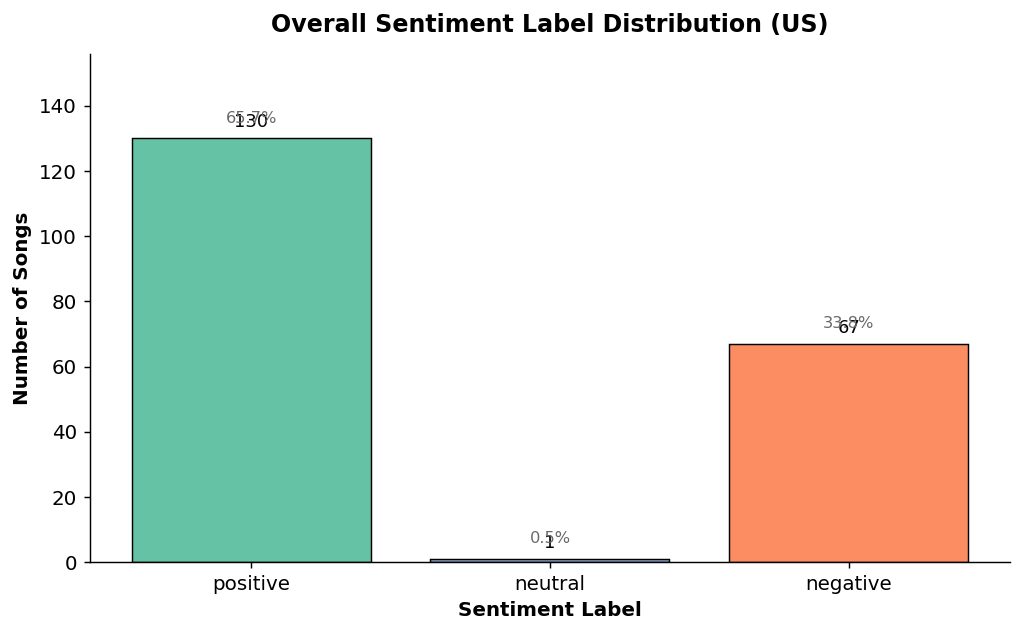

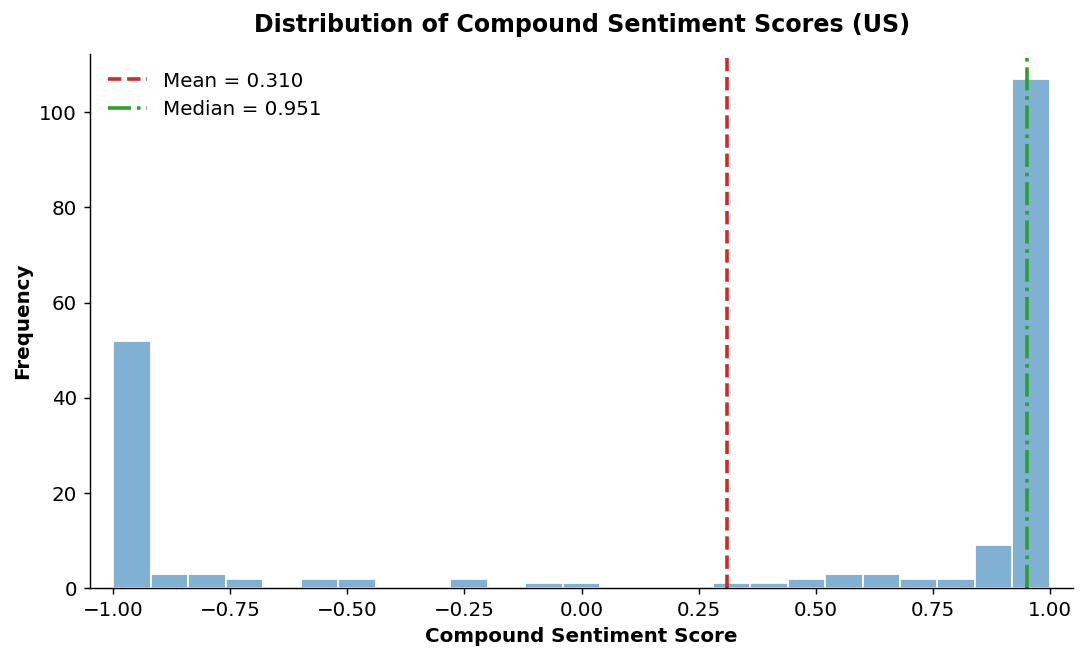

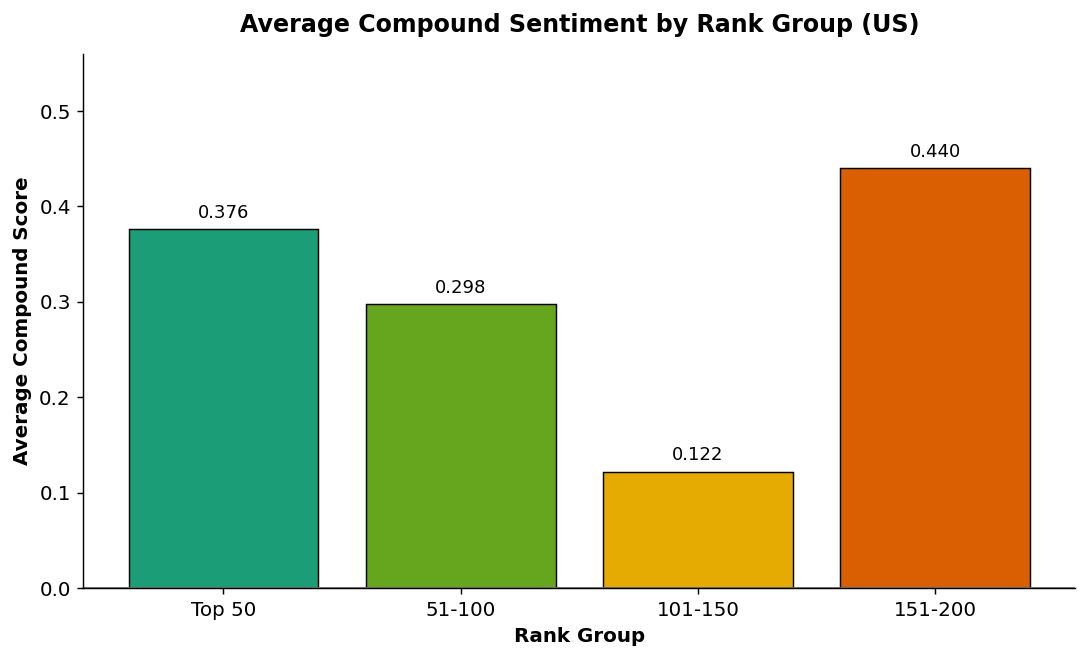

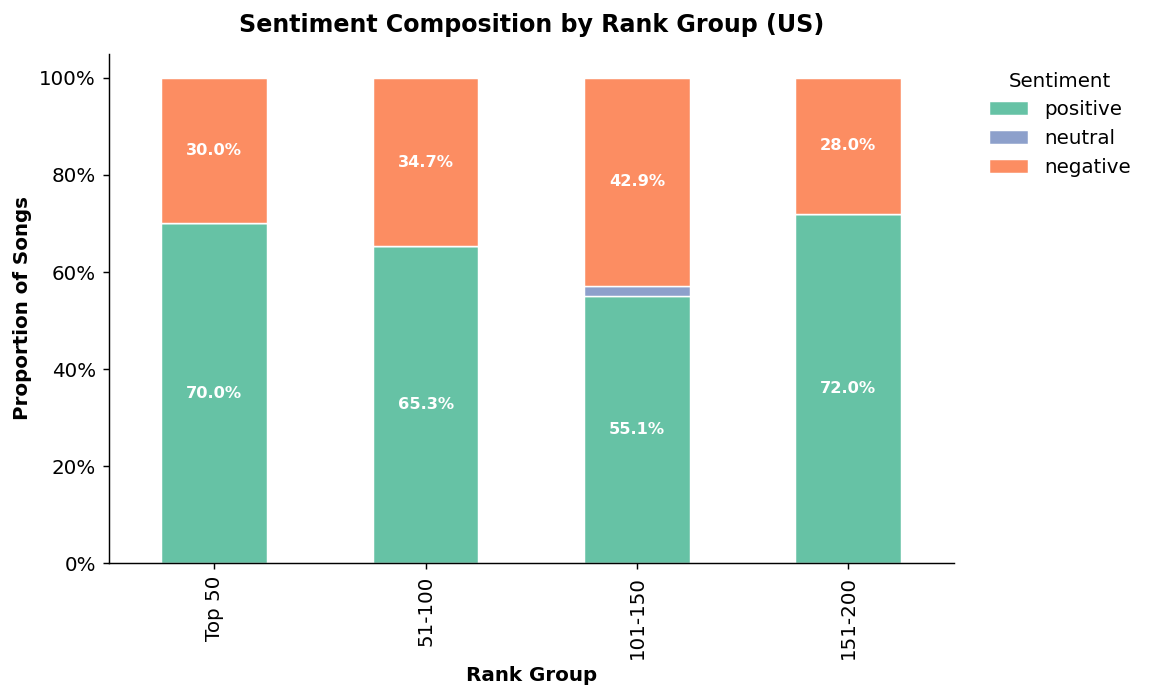


Saved: us_sentiment_analysis_results.csv


In [ ]:
# =========================
# SENTIMENT ANALYSIS - FULL SCRIPT
# =========================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
country_now = "us"
file_path = f"{country_now}_top_lyrics_cleaned.csv"
# =========================
# 0. NLTK setup
# =========================
nltk.download("vader_lexicon")

# =========================
# 1. Plot style
# =========================
plt.style.use("default")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["font.size"] = 11

# =========================
# 2. Helper functions
# =========================
def add_value_labels(ax, fmt="{:.0f}", fontsize=10):
    """
    Add labels on top of bars.
    """
    for p in ax.patches:
        height = p.get_height()
        if pd.notna(height) and height != 0:
            ax.annotate(
                fmt.format(height),
                (p.get_x() + p.get_width() / 2, height),
                ha="center",
                va="bottom",
                fontsize=fontsize,
                xytext=(0, 4),
                textcoords="offset points"
            )

def add_stacked_percentage_labels(ax, df_prop, fontsize=9):
    for i, row in enumerate(df_prop.values):
        cum = 0
        for val in row:
            if val > 0.03:  # only label if block is large enough
                ax.text(
                    i,
                    cum + val / 2,
                    f"{val:.1%}",
                    ha="center",
                    va="center",
                    fontsize=fontsize,
                    color="white",
                    fontweight="bold"
                )
            cum += val

def clean_lyrics(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = re.sub(r"\[.*?\]", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def label_sentiment(compound_score):
    """
    VADER thresholds
    """
    if compound_score >= 0.05:
        return "positive"
    elif compound_score <= -0.05:
        return "negative"
    else:
        return "neutral"

def rank_group(rank):
    """
    Group ranking into 4 intervals
    """
    if pd.isna(rank):
        return np.nan
    rank = int(rank)
    if rank <= 50:
        return "Top 50"
    elif rank <= 100:
        return "51-100"
    elif rank <= 150:
        return "101-150"
    else:
        return "151-200"

# =========================
# 3. Read data
# =========================
country_now = "us"
file_path = f"{country_now}_top_lyrics_cleaned.csv"

df = pd.read_csv(file_path)

print("Columns in dataset:")
print(df.columns.tolist())

# =========================
# 4. Column settings
# =========================
LYRICS_COL = "lyrics_clean" if "lyrics_clean" in df.columns else "lyrics"
TRACK_COL = "track_name" if "track_name" in df.columns else None
ARTIST_COL = "artist_name" if "artist_name" in df.columns else None
RANK_COL = "rank" if "rank" in df.columns else None

RANK_ORDER = ["Top 50", "51-100", "101-150", "151-200"]
SENTIMENT_ORDER = ["positive", "neutral", "negative"]

# =========================
# 5. Clean lyrics
# =========================
df["lyrics_clean"] = df[LYRICS_COL].fillna("").apply(clean_lyrics)

# remove empty lyrics
df = df[df["lyrics_clean"].str.len() > 0].copy()

print(f"\nNumber of songs after cleaning: {len(df)}")

# =========================
# 6. Sentiment scoring
# =========================
sia = SentimentIntensityAnalyzer()

def get_sentiment_scores(text):
    scores = sia.polarity_scores(text)
    return pd.Series(scores)

sent_scores = df["lyrics_clean"].apply(get_sentiment_scores)
df = pd.concat([df, sent_scores], axis=1)

# =========================
# 7. Sentiment labels
# =========================
df["sentiment_label"] = df["compound"].apply(label_sentiment)

# =========================
# 8. Rank groups
# =========================
if RANK_COL is not None:
    df["rank_group"] = df[RANK_COL].apply(rank_group)

# =========================
# 9. Summary output
# =========================
print("\n=== Overall Sentiment Summary ===")
print(df[["neg", "neu", "pos", "compound"]].describe())

print("\n=== Sentiment Label Counts ===")
print(df["sentiment_label"].value_counts(dropna=False))

print("\n=== Sentiment Label Proportions ===")
print(df["sentiment_label"].value_counts(normalize=True, dropna=False).round(3))

cols_to_show = ["lyrics_clean", "neg", "neu", "pos", "compound", "sentiment_label"]
if TRACK_COL:
    cols_to_show = [TRACK_COL] + cols_to_show
if ARTIST_COL:
    cols_to_show = [ARTIST_COL] + cols_to_show

song_sentiment_df = df[cols_to_show].copy()

print("\n=== Sample Song-level Sentiment Results ===")
print(song_sentiment_df.head(10))

# =========================
# 10. Rank group summaries
# =========================
if "rank_group" in df.columns:
    rank_sentiment = (
        df.groupby("rank_group")[["neg", "neu", "pos", "compound"]]
          .mean()
          .reindex(RANK_ORDER)
    )

    print("\n=== Average Sentiment by Rank Group ===")
    print(rank_sentiment)

    rank_label_dist = (
        pd.crosstab(df["rank_group"], df["sentiment_label"], normalize="index")
          .round(3)
          .reindex(RANK_ORDER)
          .fillna(0)
    )

    print("\n=== Sentiment Label Distribution by Rank Group ===")
    print(rank_label_dist)

# =========================
# 11. Plot 1: Overall sentiment label distribution
# =========================
label_counts = (
    df["sentiment_label"]
    .value_counts()
    .reindex(SENTIMENT_ORDER)
    .fillna(0)
)

sentiment_colors = {
    "positive": "#66c2a5",
    "neutral": "#8da0cb",
    "negative": "#fc8d62"
}

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    label_counts.index,
    label_counts.values,
    color=[sentiment_colors[x] for x in label_counts.index],
    edgecolor="black",
    linewidth=0.8
)

ax.set_title(f"Overall Sentiment Label Distribution ({country_now.upper()})", pad=12)
ax.set_xlabel("Sentiment Label")
ax.set_ylabel("Number of Songs")
ax.set_ylim(0, max(label_counts.values) * 1.20 if max(label_counts.values) > 0 else 1)

add_value_labels(ax, fmt="{:.0f}", fontsize=10)

total_n = label_counts.sum()
for i, v in enumerate(label_counts.values):
    if total_n > 0:
        ax.text(
            i,
            v + max(label_counts.values) * 0.03,
            f"{v/total_n:.1%}",
            ha="center",
            va="bottom",
            fontsize=9,
            color="dimgray"
        )

plt.tight_layout()
plt.show()

# =========================
# 12. Plot 2: Compound score histogram
# =========================
fig, ax = plt.subplots(figsize=(8.5, 5.2))

n, bins, patches = ax.hist(
    df["compound"],
    bins=25,
    color="#80b1d3",
    edgecolor="white",
    linewidth=1
)

mean_comp = df["compound"].mean()
median_comp = df["compound"].median()

ax.axvline(mean_comp, color="#d62728", linestyle="--", linewidth=2, label=f"Mean = {mean_comp:.3f}")
ax.axvline(median_comp, color="#2ca02c", linestyle="-.", linewidth=2, label=f"Median = {median_comp:.3f}")

ax.set_title(f"Distribution of Compound Sentiment Scores ({country_now.upper()})", pad=12)
ax.set_xlabel("Compound Sentiment Score")
ax.set_ylabel("Frequency")
ax.set_xlim(-1.05, 1.05)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

# =========================
# 13. Plot 3: Average compound by rank group
# =========================
if "rank_group" in df.columns:
    rank_compound = (
        df.groupby("rank_group")["compound"]
          .mean()
          .reindex(RANK_ORDER)
    )

    rank_colors = ["#1b9e77", "#66a61e", "#e6ab02", "#d95f02"]

    fig, ax = plt.subplots(figsize=(8.5, 5.2))

    bars = ax.bar(
        rank_compound.index,
        rank_compound.values,
        color=rank_colors,
        edgecolor="black",
        linewidth=0.8
    )

    ax.set_title(f"Average Compound Sentiment by Rank Group ({country_now.upper()})", pad=12)
    ax.set_xlabel("Rank Group")
    ax.set_ylabel("Average Compound Score")
    ax.axhline(0, color="gray", linewidth=1)

    ymin = min(0, rank_compound.min() - 0.08) if not rank_compound.isna().all() else 0
    ymax = rank_compound.max() + 0.12 if not rank_compound.isna().all() else 1
    ax.set_ylim(ymin, ymax)

    add_value_labels(ax, fmt="{:.3f}", fontsize=10)

    plt.tight_layout()
    plt.show()

# =========================
# 14. Plot 4: Sentiment composition by rank group
# =========================
if "rank_group" in df.columns:
    rank_label_dist_plot = (
        pd.crosstab(df["rank_group"], df["sentiment_label"], normalize="index")
          .reindex(RANK_ORDER)
          .fillna(0)
    )

    for col in SENTIMENT_ORDER:
        if col not in rank_label_dist_plot.columns:
            rank_label_dist_plot[col] = 0

    rank_label_dist_plot = rank_label_dist_plot[SENTIMENT_ORDER]

    stacked_colors = ["#66c2a5", "#8da0cb", "#fc8d62"]

    fig, ax = plt.subplots(figsize=(9, 5.5))

    rank_label_dist_plot.plot(
        kind="bar",
        stacked=True,
        color=stacked_colors,
        edgecolor="white",
        linewidth=0.8,
        ax=ax
    )

    ax.set_title(f"Sentiment Composition by Rank Group ({country_now.upper()})", pad=12)
    ax.set_xlabel("Rank Group")
    ax.set_ylabel("Proportion of Songs")
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.legend(title="Sentiment", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

    add_stacked_percentage_labels(ax, rank_label_dist_plot)

    plt.tight_layout()
    plt.show()

# =========================
# 15. Export results
# =========================
output_cols = []

for c in [TRACK_COL, ARTIST_COL, RANK_COL]:
    if c is not None:
        output_cols.append(c)

output_cols += ["lyrics_clean", "neg", "neu", "pos", "compound", "sentiment_label"]

if "rank_group" in df.columns:
    output_cols.append("rank_group")

sentiment_output = df[output_cols].copy()
sentiment_output.to_csv(f"{country_now}_sentiment_analysis_results.csv", index=False, encoding="utf-8-sig")

print(f"\nSaved: {country_now}_sentiment_analysis_results.csv")

### 2.5 Key Words

In [9]:
custom_stopwords = {
    # lyric fillers
    "yeah", "oh", "ooh", "oooh", "la", "na", "da", "uh", "ha", "mmm", "Toñita's",
    "yo", "ah", "ohh", "huh", "mm", "woo", "wuh", "ay", "uhh", "hmm", "hmmm",
    "naaa", "oohh", "aah", "aahh", "eah", "eahh", "mama", "papa", "bobby","Eh", 
    "eh", "Ayy", "Santurce", "mami", "bomba", "plena", "Beno", "ther", "dum",
    "reggaetón", "dembow", "Capea", "El", "Dough", 'ana', 'anchor', 'andr', 
    'andre', "amen", "andrew", "arm", "banister", "bea", "bebe", "bieber",
    'bom', 'bond', 'bondd', 'bondolha', 'bondpenhasco', 'bone', 'bonito', 'boo',
    'boogie', "scott", "gon", "kpop", "gecs", "danny", "krillex", "sonza", "voc",
    "eminem", "cole", "lamar", "justin", "skrrt", "nigga", "com", "mais", "ejae",
    "audrey", "nuna", "pra", "gente", "ama", "huntr", "weeknd", "yall", "tennessee",
    "thinkin", "wayne", "boyz", "hear", "escutados", "dia", "ano", "castela", "vezes",
    "joji", "eilish", "wrld", "lil", "peep", "xxxtentacion", "juice", "wrld", "lil", 
    "peep", "xxxtentacion", "juice", "ima", "uzi", "ana", "rey", "skrillex",
    "yeah", "oh", "ooh", "oooh", "mmm", "uh", "la", "na", "da",
    "got", "gonna", "wanna", "im", "ive", "youre", "youve", "dont",
    "didnt", "cant", "couldnt", "ill", "id", "thats", "theres",
    "chorus", "verse", "bridge", "intro", "outro", "repeat", "ah", "ft", "II", "III", "IV", "v", 
    "final", "explicit", "feat", "featuring", "ma", "ba", "aint", "gon", "skrrt", "nigga", "com", "mais", "ejae",
    "audrey", "nuna", "pra", "gente", "ama", "huntr", "weeknd", "yall", "tennessee",
    "thinkin", "wayne", "boyz", "hear", "escutados", "dia",

    # TRY
    "west", "kendrick", "future", "travis", "boomin", "rei", "nicki", "del", "jay",
    "guess", "dave", "probability", "malone", "billie", "lana", "woah",

    # conversational / generic lyric words
    "hey", "baby", "girl", "boy", "man", "got", "cause", "ya",

    # contraction fragments
    "don", "re", "ve", "ll", "m", "d", "s", "t", "ve",

    # full contractions without apostrophe
    "im", "ive", "youre", "dont", "didnt", "cant", "thats", "wont", "doesnt",
    "isnt", "arent", "wasnt", "werent", "couldnt", "shouldnt", "wouldnt",

    # structure words
    "chorus", "verse", "intro", "outro", "bridge", "repeat", "refrain", "post", "pre",

    # noisy tokens
    "que", "final", "explicit", "feat", "featuring", "lil", "drake", "radiohead", "cure", "kanye",
    "tyler", "know", "like", "just", "come", "let", "say", "make",
    "want", "wanna", "gonna", "tell", "time", "good", "new", "ariana", "grande", "taylor", "swift",
    "love", "jennie", "creator", "chanel", "dracula", "maria", "jose", "michael", "jackson", "beyonce", "rihanna",
    "ayy", "mum", "ami", "amor", "doo", "do", "did", "is", "are", "was", "were", "be", "been", "have", "has", "had",

}

Columns in dataset:
['rank', 'track_artist', 'peak', 'prev', 'streak', 'streams', 'track_name', 'artist_name', 'genius_url', 'lyrics', 'genius_url_org', 'english_translation_url', 'has_english_translation', 'lyrics_clean', 'verse_1_count', 'verse_2_count', 'chorus_count', 'post_chorus_count', 'verse_total_count', 'pre_chorus_count', 'bridge_count', 'intro_count', 'outro_count', 'hook_count', 'refrain_count', 'all_section_labels']

Number of songs after cleaning: 198

=== Top 20 Unigrams ===
    ngram  count
0     don    538
1    know    500
2    like    490
3    just    441
4    love    390
5    baby    343
6      ll    296
7      ve    293
8     let    239
9    time    216
10  night    203
11  cause    201
12    say    200
13    way    193
14   want    191
15    ain    164
16     ft    163
17     ah    157
18   tell    157
19   girl    157

=== Top 20 Bigrams ===
            ngram  count
0           oh oh    290
1           la la    117
2       yeah yeah     91
3         ooh ooh     8

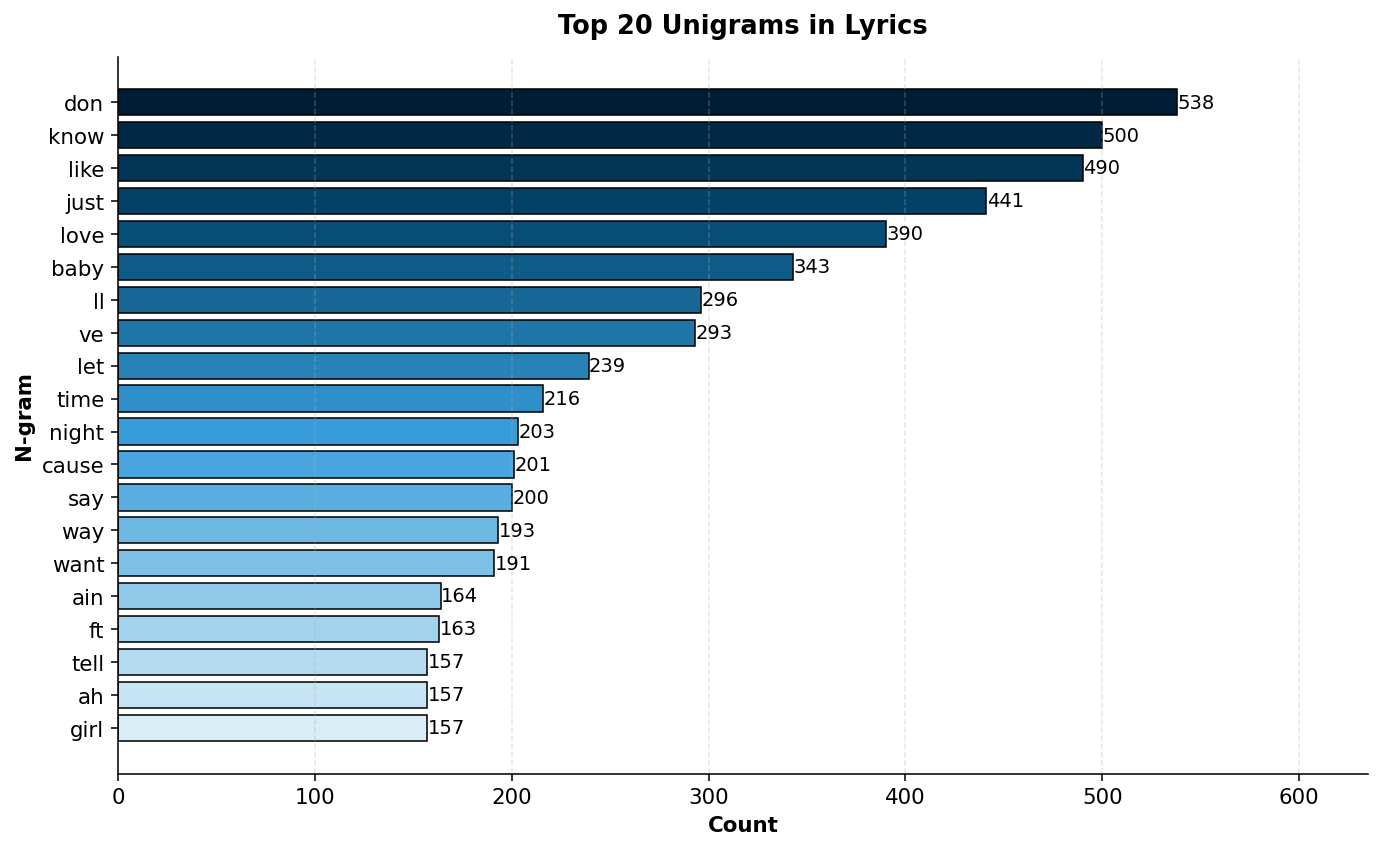

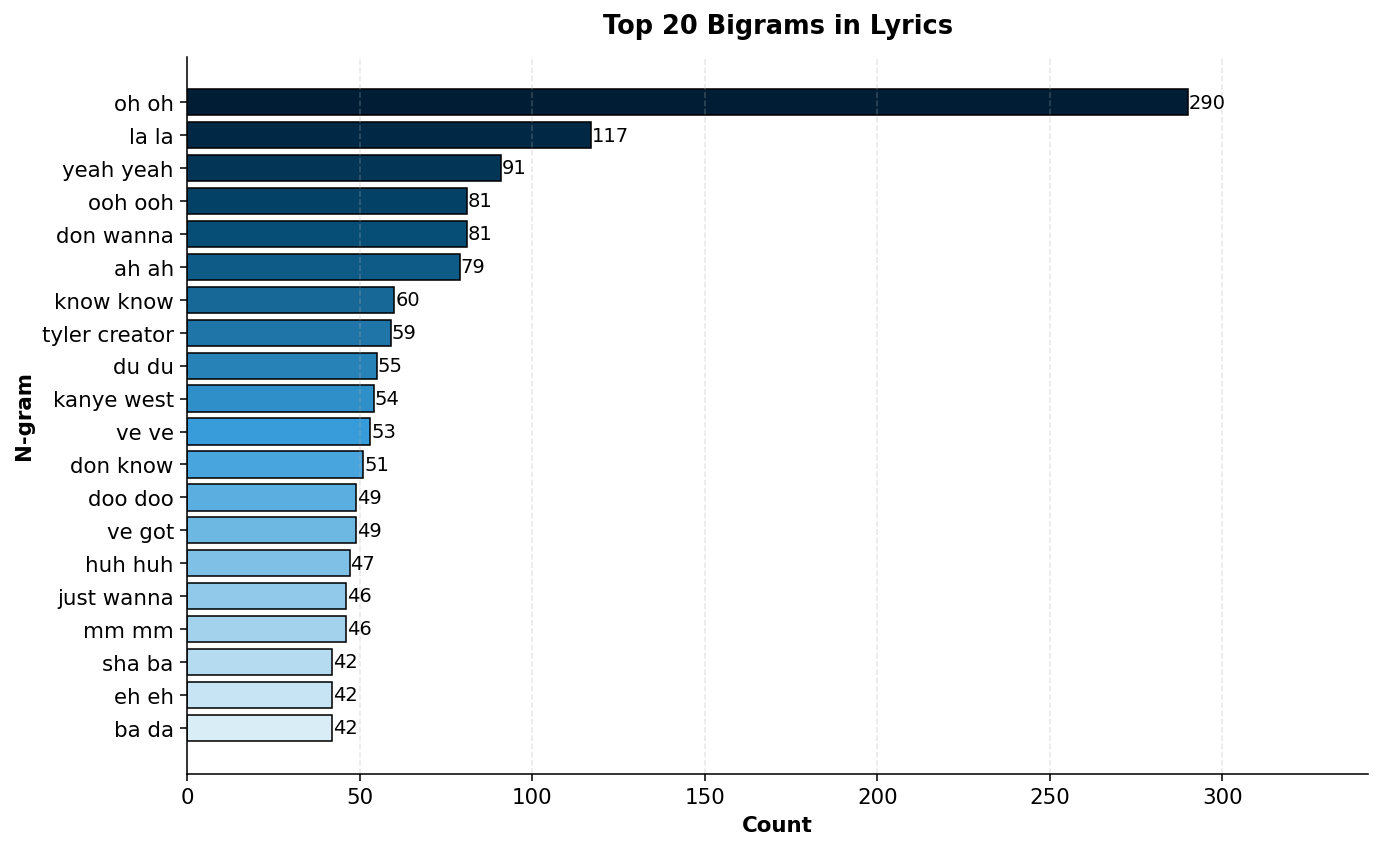

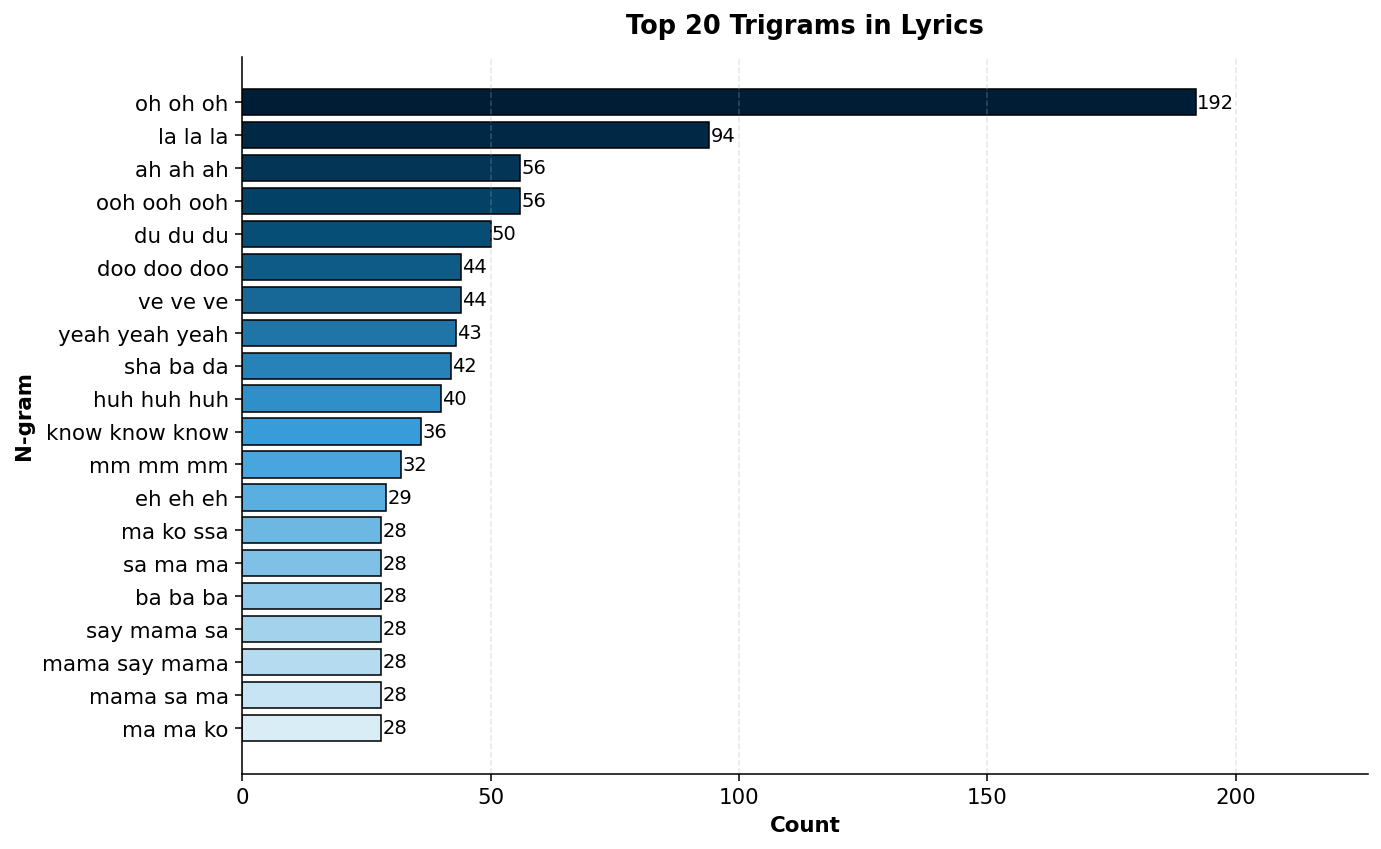

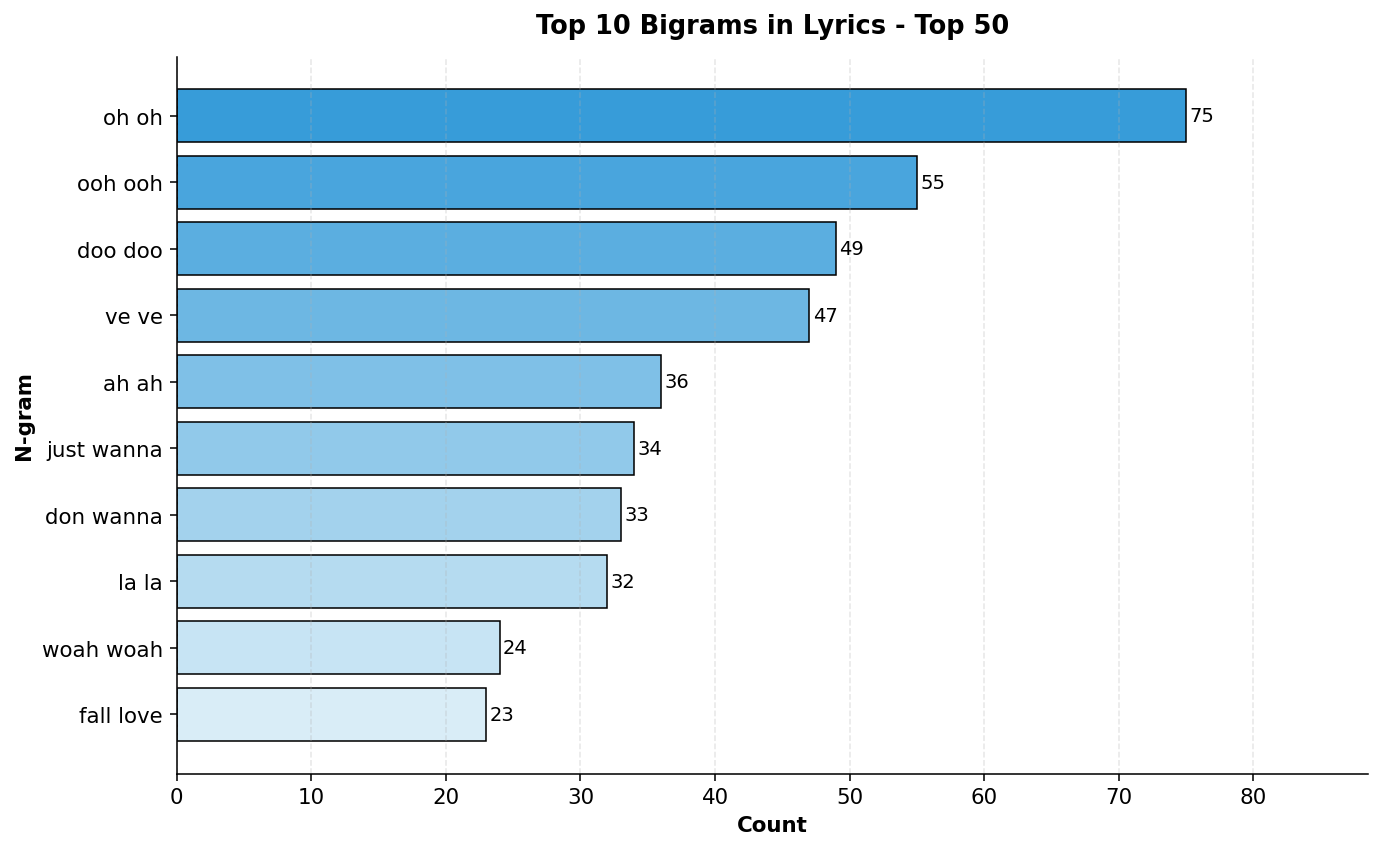

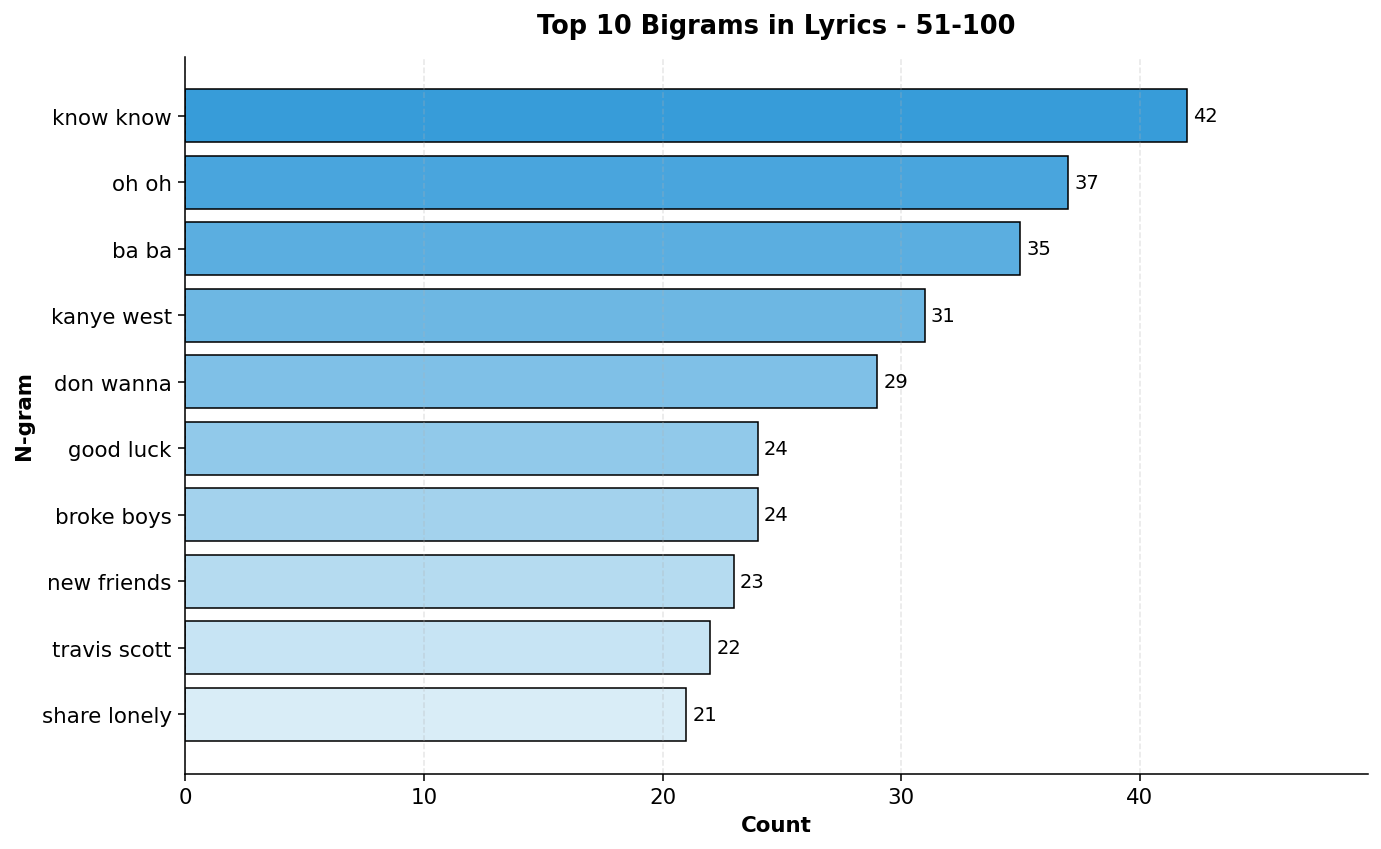

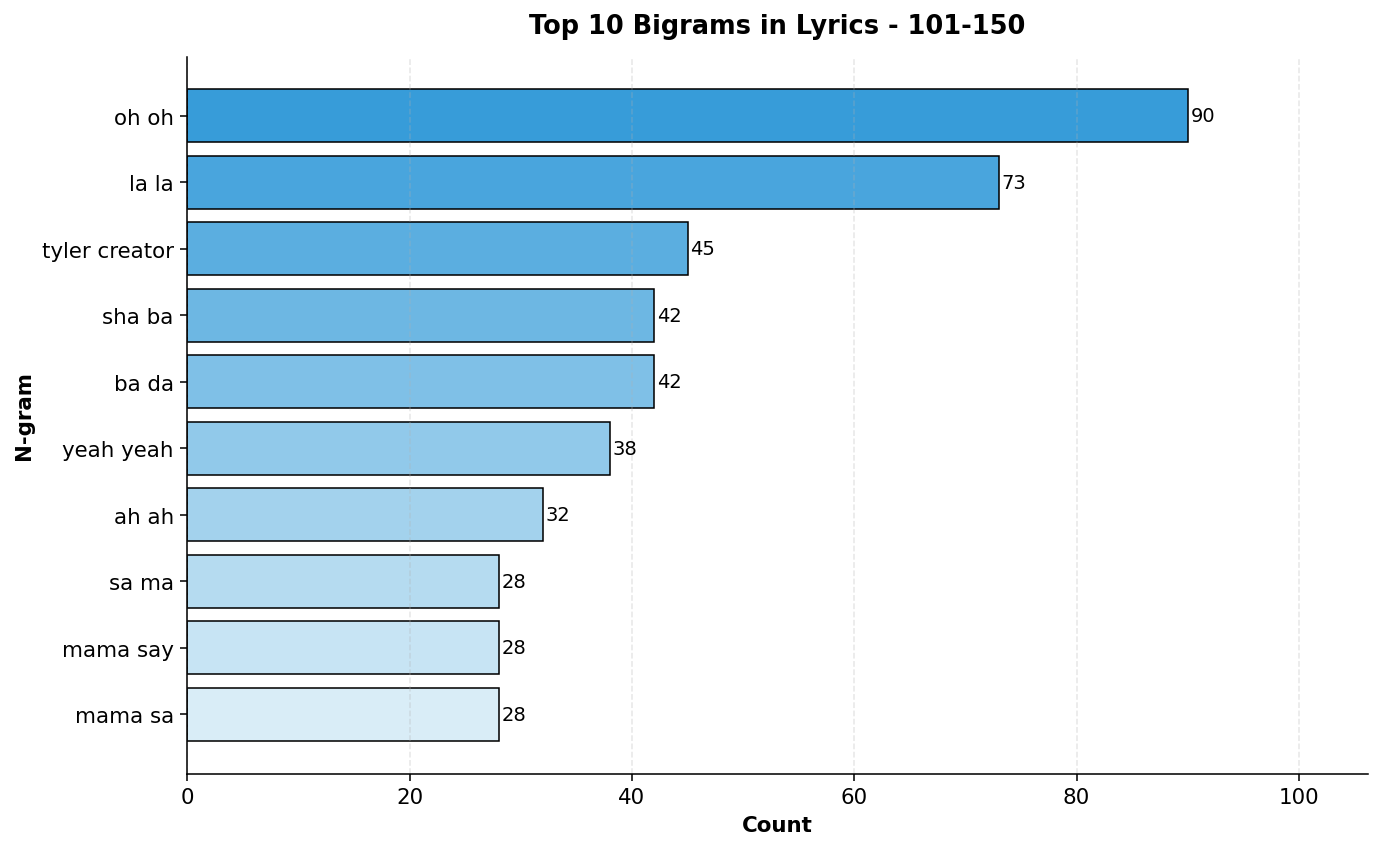

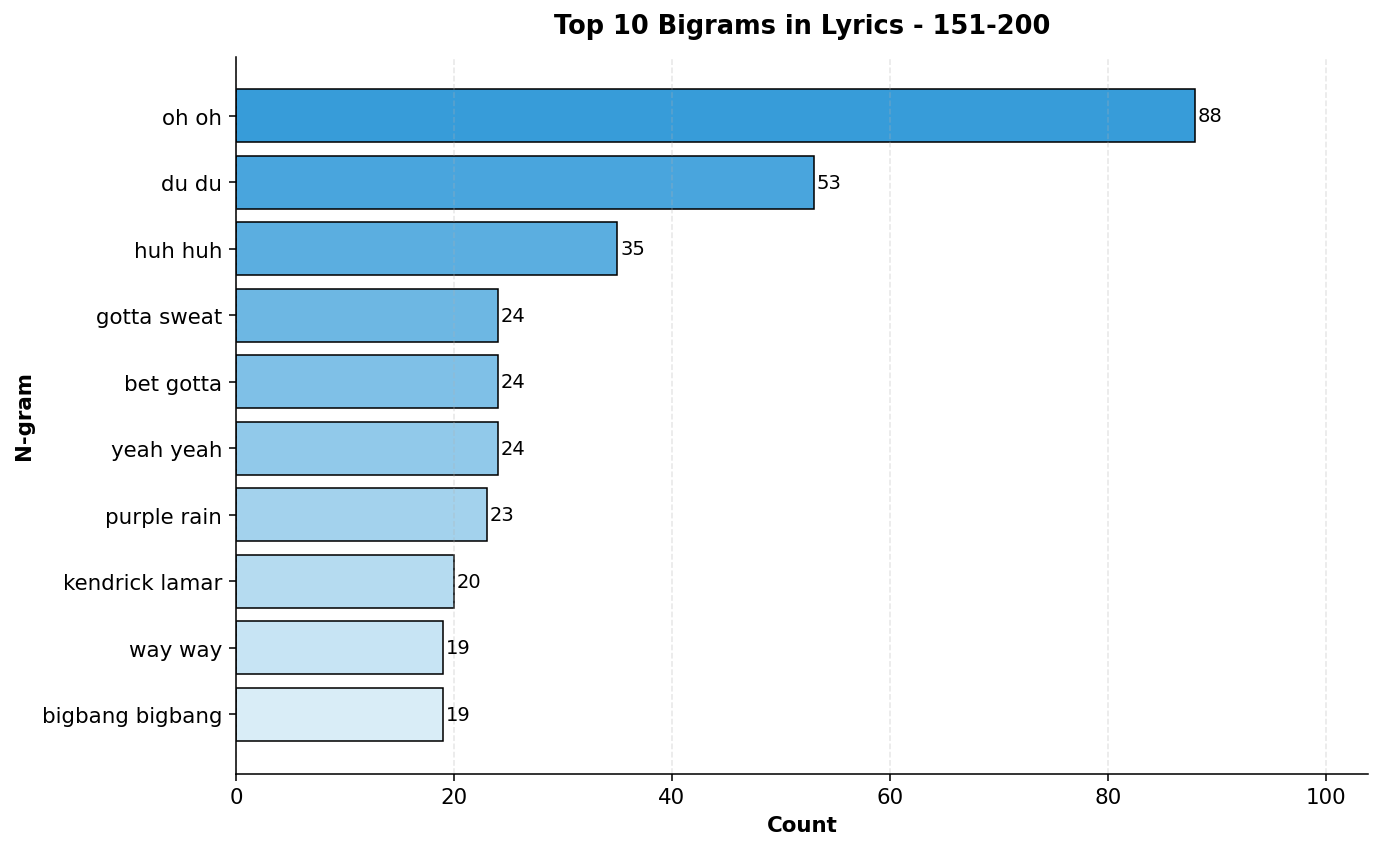


Saved:
- top_unigrams.csv
- top_bigrams.csv
- top_trigrams.csv
- rankgroup_top_bigrams.csv


In [ ]:
# =========================
# 2. KEYWORD / N-GRAM ANALYSIS
# =========================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

# =========================
# A. Read data
# =========================
country_now = "us"
file_path = f"{country_now}_top_lyrics_cleaned.csv"
df = pd.read_csv(file_path)

print("Columns in dataset:")
print(df.columns.tolist())


# =========================
# B. Column settings
# =========================
LYRICS_COL = "lyrics"
TRACK_COL = "track_name" if "track_name" in df.columns else None
ARTIST_COL = "artist_name" if "artist_name" in df.columns else None
RANK_COL = "rank" if "rank" in df.columns else None


# =========================
# C. Basic lyric cleaning before keyword analysis
# =========================
def clean_lyrics(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = re.sub(r"\[.*?\]", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["lyrics_clean"] = df[LYRICS_COL].fillna("").apply(clean_lyrics)
df = df[df["lyrics_clean"].str.len() > 0].copy()

print(f"\nNumber of songs after cleaning: {len(df)}")


# =========================
# D. rank group
# =========================
if RANK_COL is not None:
    def rank_group(rank):
        if pd.isna(rank):
            return np.nan
        rank = int(rank)
        if rank <= 50:
            return "Top 50"
        elif rank <= 100:
            return "51-100"
        elif rank <= 150:
            return "101-150"
        else:
            return "151-200"

    df["rank_group"] = df[RANK_COL].apply(rank_group)


# =========================
# E. n-gram extraction function
# =========================
def get_top_ngrams(text_series, ngram_range=(1, 1), top_n=20, min_df=1):
    """
    從一組文字中抽出 top n n-grams
    """
    text_series = text_series.dropna().astype(str)
    text_series = text_series[text_series.str.strip() != ""]

    if len(text_series) == 0:
        return pd.DataFrame(columns=["ngram", "count"])

    vectorizer = CountVectorizer(
        stop_words="english",
        ngram_range=ngram_range,
        min_df=min_df
    )

    X = vectorizer.fit_transform(text_series)
    counts = np.asarray(X.sum(axis=0)).flatten()
    vocab = np.array(vectorizer.get_feature_names_out())

    result = pd.DataFrame({
        "ngram": vocab,
        "count": counts
    }).sort_values("count", ascending=False)

    # 去掉 custom stopword 影響（對 unigram 特別有用）
    if ngram_range == (1, 1):
        result = result[~result["ngram"].isin(custom_stopwords)]

    return result.head(top_n).reset_index(drop=True)


# =========================
# F. overall unigrams / bigrams / trigrams
# =========================
top_unigrams = get_top_ngrams(df["lyrics_clean"], ngram_range=(1, 1), top_n=20)
top_bigrams = get_top_ngrams(df["lyrics_clean"], ngram_range=(2, 2), top_n=20)
top_trigrams = get_top_ngrams(df["lyrics_clean"], ngram_range=(3, 3), top_n=20)

print("\n=== Top 20 Unigrams ===")
print(top_unigrams)

print("\n=== Top 20 Bigrams ===")
print(top_bigrams)

print("\n=== Top 20 Trigrams ===")
print(top_trigrams)


# =========================
# G. by rank group n-grams
# =========================
rank_bigram_results = {}

if "rank_group" in df.columns:
    for rg, group in df.groupby("rank_group"):
        top_rank_bigrams = get_top_ngrams(
            group["lyrics_clean"],
            ngram_range=(2, 2),
            top_n=10
        )
        rank_bigram_results[rg] = top_rank_bigrams

    print("\n=== Top Bigrams by Rank Group ===")
    for rg in ["Top 50", "51-100", "101-150", "151-200"]:
        if rg in rank_bigram_results:
            print(f"\nRank Group: {rg}")
            print(rank_bigram_results[rg])

# =========================
# H. Plotting function for top n-grams
# =========================
def plot_top_ngrams(df_ngram, title):
    if df_ngram.empty:
        print(f"No data available for: {title}")
        return

    plot_df = df_ngram.sort_values("count", ascending=True).copy()

    plt.style.use("default")
    plt.rcParams["figure.dpi"] = 140
    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False
    plt.rcParams["font.size"] = 11
    plt.rcParams["axes.titleweight"] = "bold"
    plt.rcParams["axes.labelweight"] = "bold"

    colors = [
        "#d9edf7", "#c7e4f4", "#b5dbf0", "#a3d2ed", "#91c9ea",
        "#7fc0e7", "#6db7e3", "#5baee0", "#49a5dd", "#379cd9",
        "#2f8fc9", "#2782b8", "#1f75a8", "#176897", "#0f5b87",
        "#074e76", "#034166", "#023556", "#012946", "#001d36"
    ]

    fig, ax = plt.subplots(figsize=(10, 6.2))

    bars = ax.barh(
        plot_df["ngram"],
        plot_df["count"],
        color=colors[:len(plot_df)],
        edgecolor="black",
        linewidth=0.8
    )

    for bar in bars:
        width = bar.get_width()
        ax.text(
            width + 0.25,
            bar.get_y() + bar.get_height() / 2,
            f"{int(width)}",
            va="center",
            ha="left",
            fontsize=10,
            color="black"
        )

    ax.set_title(title, pad=12)
    ax.set_xlabel("Count")
    ax.set_ylabel("N-gram")
    ax.set_xlim(0, plot_df["count"].max() * 1.18)
    ax.grid(axis="x", linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.show()


# =========================
# I. overall plots
# =========================
plot_top_ngrams(top_unigrams, "Top 20 Unigrams in Lyrics")
plot_top_ngrams(top_bigrams, "Top 20 Bigrams in Lyrics")
plot_top_ngrams(top_trigrams, "Top 20 Trigrams in Lyrics")


# =========================
# J. by rank group plots
# =========================
if "rank_group" in df.columns:
    for rg in ["Top 50", "51-100", "101-150", "151-200"]:
        if rg in rank_bigram_results:
            plot_top_ngrams(
                rank_bigram_results[rg],
                f"Top 10 Bigrams in Lyrics - {rg}"
            )


# =========================
# K. Output overall result
# =========================
top_unigrams.to_csv("top_unigrams.csv", index=False, encoding="utf-8-sig")
top_bigrams.to_csv("top_bigrams.csv", index=False, encoding="utf-8-sig")
top_trigrams.to_csv("top_trigrams.csv", index=False, encoding="utf-8-sig")

print("\nSaved:")
print("- top_unigrams.csv")
print("- top_bigrams.csv")
print("- top_trigrams.csv")


# =========================
# M. Output rank group bigrams
# =========================
if "rank_group" in df.columns:
    rank_ngram_all = []

    for rg, temp_df in rank_bigram_results.items():
        temp = temp_df.copy()
        temp["rank_group"] = rg
        rank_ngram_all.append(temp)

    if rank_ngram_all:
        rank_ngram_all = pd.concat(rank_ngram_all, ignore_index=True)
        rank_ngram_all.to_csv("rankgroup_top_bigrams.csv", index=False, encoding="utf-8-sig")
        print("- rankgroup_top_bigrams.csv")